**Market Basket Analysis with Python - Target**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

Target = pd.read_csv('/content/drive/MyDrive/Target.csv')

In [ ]:
Target.head()
Target.shape
Target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   620 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

**Task 1: Data Cleaning and Preparation**

**Task 1.1 Remove duplicate or inconsistent survey responses.**

In [ ]:
# Part A
# Step 1: Check for Duplicates
Target.duplicated().sum()


# Part B
# Step 2 Then inspect inconsistent categorical responses in each column:
for items in Target.columns:
    print(items, Target[items].unique())

# Two Inconsistency Found:
# Service_Appreciation column has a suspicious "." value and also "Customer service" vs "Customer service " with an extra trailing space.
# Improvement_Areas contains ".", "Nil", "Nothing", and several variations of "no problem," which may need standardization.

# Step 3 Check Service_Appreciation Column
Target["Service_Appreciation"].unique()
# Step 4 To Remove Extra "."
import numpy as np
Target["Service_Appreciation"]= Target["Service_Appreciation"].replace(".","No Feedback Specified")

# Step 5 To Fix trailing space in "Customer service" vs "Customer service "
Target["Service_Appreciation"]=Target["Service_Appreciation"].str.strip()


Target['Service_Appreciation'].unique()




Timestamp ['2023/06/08 5:20:57 PM GMT+5:30' '2023/06/12 2:44:47 PM GMT+5:30'
 '2023/06/09 2:39:16 PM GMT+5:30' '2023/06/08 7:33:15 AM GMT+5:30'
 '2023/06/11 11:01:04 PM GMT+5:30' '2023/06/08 3:30:19 AM GMT+5:30'
 '2023/06/08 5:28:47 PM GMT+5:30' '2023/06/09 3:09:41 PM GMT+5:30'
 '2023/06/09 2:44:09 PM GMT+5:30' '2023/06/08 3:24:37 AM GMT+5:30'
 '2023/06/09 3:23:38 PM GMT+5:30' '2023/06/06 6:51:13 PM GMT+5:30'
 '2023/06/05 2:16:16 PM GMT+5:30' '2023/06/11 10:44:01 PM GMT+5:30'
 '2023/06/08 3:23:36 AM GMT+5:30' '2023/06/09 4:32:56 PM GMT+5:30'
 '2023/06/08 6:01:33 PM GMT+5:30' '2023/06/12 3:33:53 PM GMT+5:30'
 '2023/06/06 7:46:27 PM GMT+5:30' '2023/06/08 5:19:41 PM GMT+5:30'
 '2023/06/09 9:33:35 AM GMT+5:30' '2023/06/09 3:07:36 PM GMT+5:30'
 '2023/06/11 11:04:55 PM GMT+5:30' '2023/06/04 9:10:51 PM GMT+5:30'
 '2023/06/08 5:54:49 PM GMT+5:30' '2023/06/05 2:24:22 PM GMT+5:30'
 '2023/06/09 2:42:24 PM GMT+5:30' '2023/06/08 5:30:34 PM GMT+5:30'
 '2023/06/08 5:42:27 PM GMT+5:30' '2023/06/07 9:2

array(['Customer service', 'Competitive prices', 'No Feedback Specified',
       'Product recommendations', 'User-friendly website/app interface',
       'Wide product selection', 'All the above', 'Quick delivery'],
      dtype=object)

**Task 1.2 Standardize categorical/numerical entries (e.g., frequency levels, gender, recommendation responses).**

In [ ]:
# Step 1 Find numerical columns
Target.select_dtypes(include="number")

# The numerical columns are already fairly standardized in terms of their ranges:

# Step 2 Show categorical Columns
Target.select_dtypes(include="object").columns

# Step 3 To inspect all unique items categorical/text columns
for col in Target.select_dtypes(include="object").columns:
    print(col, Target[col].unique())
# Step 4 Check each items of columns and remove spaces

for col in Target.select_dtypes(include="object").columns:
    Target[col] = Target[col].str.strip()

# Step 5 Fix the categories item in "Product_Search_Method" Column
Target['Product_Search_Method'] = Target['Product_Search_Method'].replace(
    'categories', 'Categories')


Timestamp ['2023/06/08 5:20:57 PM GMT+5:30' '2023/06/12 2:44:47 PM GMT+5:30'
 '2023/06/09 2:39:16 PM GMT+5:30' '2023/06/08 7:33:15 AM GMT+5:30'
 '2023/06/11 11:01:04 PM GMT+5:30' '2023/06/08 3:30:19 AM GMT+5:30'
 '2023/06/08 5:28:47 PM GMT+5:30' '2023/06/09 3:09:41 PM GMT+5:30'
 '2023/06/09 2:44:09 PM GMT+5:30' '2023/06/08 3:24:37 AM GMT+5:30'
 '2023/06/09 3:23:38 PM GMT+5:30' '2023/06/06 6:51:13 PM GMT+5:30'
 '2023/06/05 2:16:16 PM GMT+5:30' '2023/06/11 10:44:01 PM GMT+5:30'
 '2023/06/08 3:23:36 AM GMT+5:30' '2023/06/09 4:32:56 PM GMT+5:30'
 '2023/06/08 6:01:33 PM GMT+5:30' '2023/06/12 3:33:53 PM GMT+5:30'
 '2023/06/06 7:46:27 PM GMT+5:30' '2023/06/08 5:19:41 PM GMT+5:30'
 '2023/06/09 9:33:35 AM GMT+5:30' '2023/06/09 3:07:36 PM GMT+5:30'
 '2023/06/11 11:04:55 PM GMT+5:30' '2023/06/04 9:10:51 PM GMT+5:30'
 '2023/06/08 5:54:49 PM GMT+5:30' '2023/06/05 2:24:22 PM GMT+5:30'
 '2023/06/09 2:42:24 PM GMT+5:30' '2023/06/08 5:30:34 PM GMT+5:30'
 '2023/06/08 5:42:27 PM GMT+5:30' '2023/06/07 9:2

**Task 1.3  Handle missing values and inconsistent formats in   Product_Search_Method and other fields.**

In [ ]:
# Step 1 Check which column have missing values
Target.isna().sum()
# Step 2 Replaced Null Values with “Unknown”
Target["Product_Search_Method"]=Target["Product_Search_Method"].fillna("Unknown")
# Step -3 Checked "Product_Search_Method" Column
Target["Product_Search_Method"].value_counts()

,count
Product_Search_Method,
Unknown,180
Keyword,173
others,158
Filter,157
Categories,132


**Task 1.4 Rename duplicate or misformatted columns (e.g., remove trailing spaces in Rating_Accuracy )**

In [ ]:
# Step 1 Check all column names
Target.columns

# Step 2 Target.columns = Target.columns.str.strip()
Target.columns = Target.columns.str.strip()

# Step 3  Check whether any column name contains spaces
Target.columns[Target.columns.str.contains(' ')]

Index([], dtype='object')

**Task 1.4 Part -B Rename duplicate or misformatted columns (e.g., remove trailing spaces in Rating_Accuracy )**

In [ ]:
Target.iloc[ :,5].head(10)  # For Accessing Column 5
Target.iloc[ :,17].head(10) # For Accessing Column 7
# Step 1 Inspected Column 5, have Categorical values
Target.iloc[:, 5].value_counts()  # checked Have Categorical values
# Inspected Column 17, have numerical values
Target.iloc[:, 17].value_counts().sort_index() # checked Have Numerical values

# Since both columns have different cell properties
# Renaming Column Titles
Target.columns.values[5] = "Personalized_Recommendation_Frequency_Response"
Target.columns.values[17]=  "Personalized_Recommendation_Frequency_Score"
Target.head(2)


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency_Response,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 5:20:57 PM GMT+5:30,24,Others,Once a month,Clothing and Fashion;others,No,Rarely,Keyword,First page,1,...,No,Heavily,Yes,4,Sometimes,2,1,Customer service,I don't have any problem with Amazon,567877
1,2023/06/12 2:44:47 PM GMT+5:30,12,Male,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Categories,First page,5,...,Yes,Occasionally,Yes,4,Sometimes,5,3,Competitive prices,Nil,313221


In [ ]:
Target["Timestamp"]=pd.to_datetime(Target["Timestamp"],dayfirst=True, format="mixed")
Target.dtypes

,0
Timestamp,"datetime64[ns, UTC-05:30]"
age,int64
Gender,object
Purchase_Frequency,object
Purchase_Categories,object
Personalized_Recommendation_Frequency_Response,object
Browsing_Frequency,object
Product_Search_Method,object
Search_Result_Exploration,object
Customer_Reviews_Importance,int64


In [ ]:
Target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                          Non-Null Count  Dtype                    
---  ------                                          --------------  -----                    
 0   Timestamp                                       800 non-null    datetime64[ns, UTC-05:30]
 1   age                                             800 non-null    int64                    
 2   Gender                                          800 non-null    object                   
 3   Purchase_Frequency                              800 non-null    object                   
 4   Purchase_Categories                             800 non-null    object                   
 5   Personalized_Recommendation_Frequency_Response  800 non-null    object                   
 6   Browsing_Frequency                              800 non-null    object                   
 7   Product_Search_Method              

**Task 2: Descriptive Behavior Analysis**

**Task 2.1 Summarize customer demographics (age, gender distribution).**

In [ ]:
# Part A
# Step 1 Describe Age Summary Column
print("Age Summary:")
Target["age"].describe()

Age Summary:


,age
count,800.000000
mean,34.737500
std,18.938306
min,3.000000
25%,18.000000
50%,34.000000
75%,50.250000
max,67.000000


In [ ]:
# Part B
# Step 2 Gender Analysis
#Counts how many customers belong to each gender
print("Gender Distribution")
Target["Gender"].value_counts()

Gender Distribution


,count
Gender,
Male,214
Female,201
Others,196
Prefer not to say,189


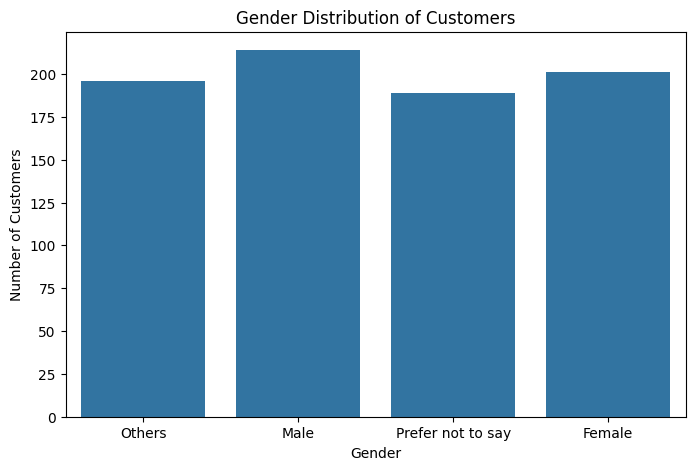

In [ ]:
# Part C Gender Visualization
# Step 3 Using Seaborn to plot Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5)) # Here 8 is width and 5 is height

sns.countplot(x=Target["Gender"])
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

**Task 2.2 Analyze overall purchase frequency and most popular product categories**

In [ ]:
# Part A
# Step 1 Show all Columns
Target.columns.tolist()
# Step 2
Target["Purchase_Frequency"].value_counts()
# Overall, purchase frequency is distributed across five categories.
# The most common purchase frequency is multiple times a week, with 173 customers, while once a week is the least common, with 142 customers.



,count
Purchase_Frequency,
Multiple times a week,173
Less than once a month,168
Once a month,164
Few times a month,153
Once a week,142


In [ ]:
# step 3
Target["Purchase_Frequency"].mode()


,Purchase_Frequency
0,Multiple times a week


In [ ]:
#Part B Identify Most most popular product categories
Target["Purchase_Categories"].mode()
#Target["Purchase_Categories"].value_counts()

#Most most popular product categories is (0	Groceries and Gourmet Food;Beauty and Personal) 37 times

,Purchase_Categories
0,Groceries and Gourmet Food;Beauty and Personal...


**Task 1.3 Identify top browsing methods and most common cart abandonment factors.**

In [ ]:
# Step 1 To Investigate have required columns are available in Dataset
Target.columns.tolist()
Target[["Browsing_Frequency",'Cart_Abandonment_Factors']]

,Browsing_Frequency,Cart_Abandonment_Factors
0,Rarely,others
1,Few times a month,Changed my mind or no longer need the item
2,Multiple times a day,others
3,Multiple times a day,Found a better price elsewhere
4,Few times a month,Found a better price elsewhere
...,...,...
795,Multiple times a day,Changed my mind or no longer need the item
796,Rarely,others
797,Multiple times a day,Changed my mind or no longer need the item
798,Few times a week,others


In [ ]:
# Part A
# Step 1
Target["Browsing_Frequency"].value_counts()

,count
Browsing_Frequency,
Multiple times a day,207
Rarely,200
Few times a month,197
Few times a week,196


In [ ]:
# Part B
# Step 2
Target['Cart_Abandonment_Factors'].mode()
#Target['Cart_Abandonment_Factors'].value_counts()

,Cart_Abandonment_Factors
0,High shipping costs


**Task 2.4 Calculate mean and median satisfaction, recommendation helpfulness, and rating accuracy.**

In [ ]:
# Step 1 To investigate have required columns are available in Dataset
Target.columns.tolist()
Target[["Shopping_Satisfaction",'Recommendation_Helpfulness','Rating_Accuracy']]

,Shopping_Satisfaction,Recommendation_Helpfulness,Rating_Accuracy
0,1,Sometimes,2
1,3,Sometimes,5
2,2,Yes,3
3,4,Sometimes,1
4,5,No,2
...,...,...,...
795,5,Sometimes,2
796,2,Yes,2
797,2,Yes,4
798,1,Yes,3


In [ ]:
# Step 2 Calculate mean for Shopping_Satisfaction
Target["Shopping_Satisfaction"].mean()

np.float64(2.935)

In [ ]:
# Step 3 Calculate median for Shopping_Satisfaction
Target["Shopping_Satisfaction"].median()

3.0

This means:

Average shopping satisfaction = 2.935 out of 5
Median satisfaction = 3 out of 5

The average is close to the middle of the 1–5 scale,
so overall satisfaction is moderate.

In [ ]:
# Step 4 Calculate mean for Recommendation_Helpfulness
Target["Recommendation_Helpfulness"].value_counts()

,count
Recommendation_Helpfulness,
Sometimes,270
Yes,265
No,265


As "Recommendation_Helpfulness" is in Categorical Text Format, so couldn't perform mean or median neither.

But we can analyze the distribution:

Sometimes → 270 customers (33.75%)
Yes → 265 customers (33.125%)
No → 265 customers (33.125%)

So the responses are almost perfectly evenly distributed.

In [ ]:
# Step 5 Calculate mean for Rating_Accuracy
Target["Rating_Accuracy"].mean()

np.float64(3.05875)

In [ ]:
# Step 6 Calculate median for Rating_Accuracy
Target["Rating_Accuracy"].median()

3.0

This means:

Average rating accuracy = 3.06 out of 5

Median rating accuracy = 3 out of 5

Customers generally gave a moderate rating for rating accuracy.

**Task 2.5 Generate summary statistics and visualizations for key behavioral variables**

Calculate mean for Shopping_Satisfaction
Target["Shopping_Satisfaction"].mean()

Return np.float64(2.935)

# On average, customers have a shopping satisfaction of 2.935 out of 5, which is around the middle of the scale.

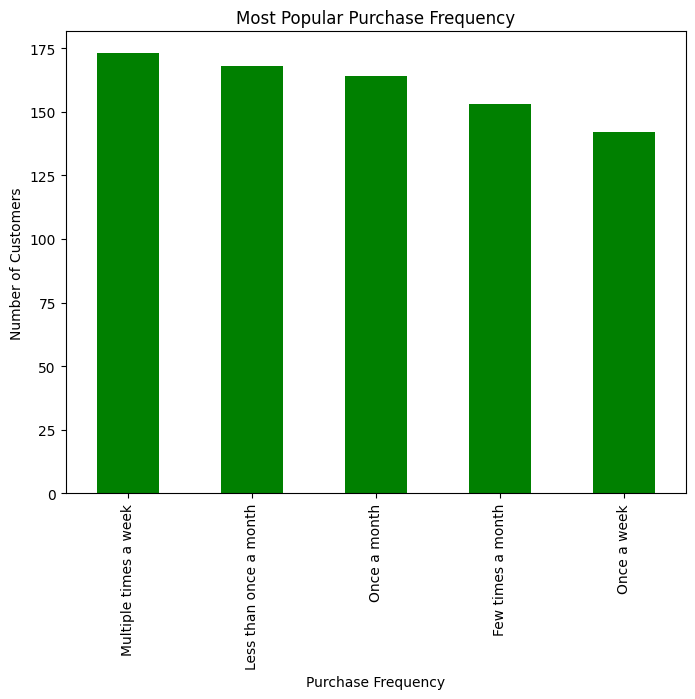

In [ ]:
# Visualisation  1 (Most Popular Purchase Frequency)
freq=Target["Purchase_Frequency"].value_counts()
freq.plot(kind="bar", color="green", figsize=(8, 6))
plt.title("Most Popular Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)

plt.show()

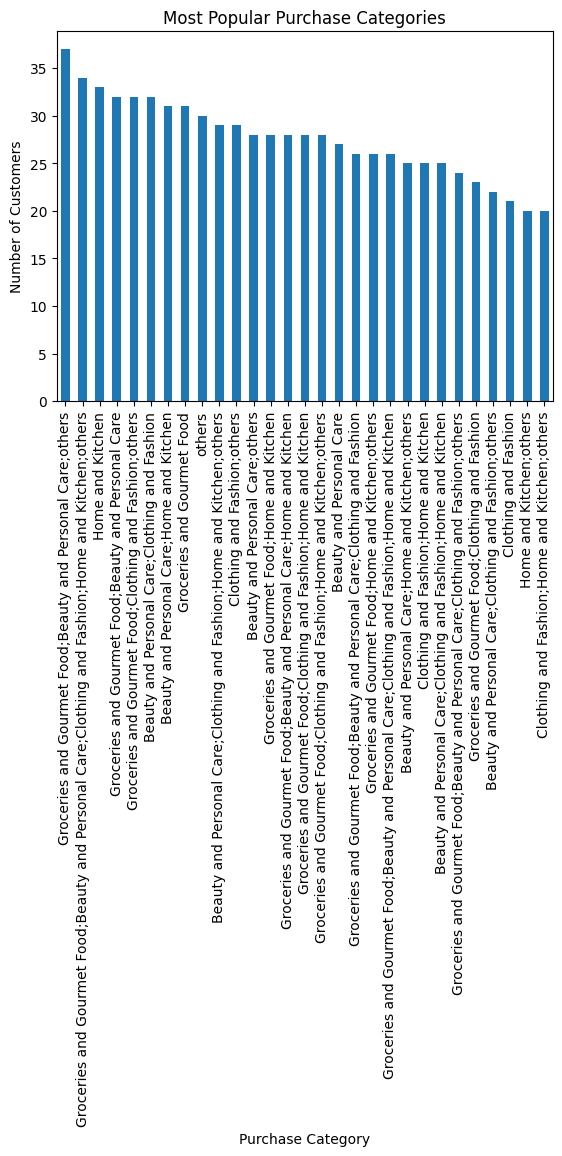

In [ ]:
# Visualisation  2 (Most Popular Purchase Categories)
Target["Purchase_Categories"].value_counts().plot(kind="bar")

plt.title("Most Popular Purchase Categories")
plt.xlabel("Purchase Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)

plt.show()


In [ ]:
"""shop_freq = pd.DataFrame({
    'Browsing Frequency': Target['Browsing_Frequency'].value_counts(),
    'Purchase Frequency': Target['Purchase_Frequency'].value_counts()
}).fillna(0)
shop_freq.plot(kind='bar', width=0.8, color=['skyblue', 'orange'], figsize=(10, 6))
plt.title("Browsing Frequency")
plt.ylabel(" ")
plt.show()"""

'shop_freq = pd.DataFrame({\n    \'Browsing Frequency\': Target[\'Browsing_Frequency\'].value_counts(),\n    \'Purchase Frequency\': Target[\'Purchase_Frequency\'].value_counts()\n}).fillna(0)\nshop_freq.plot(kind=\'bar\', width=0.8, color=[\'skyblue\', \'orange\'], figsize=(10, 6))\nplt.title("Browsing Frequency")\nplt.ylabel(" ")\nplt.show()'

**Task 3: Customer Segmentation and Profiling**

**Task 3.1 Segment customers based on purchase frequency and shopping satisfaction levels.**

In [ ]:
# Step 1 Segment both Purchase_Frequency" & "Shopping_Satisfaction columns
Target.groupby(["Purchase_Frequency", "Shopping_Satisfaction"]).size()

Purchase_Frequency      Shopping_Satisfaction
Few times a month       1                        41
                        2                        25
                        3                        28
                        4                        30
                        5                        29
Less than once a month  1                        36
                        2                        41
                        3                        26
                        4                        23
                        5                        42
Multiple times a week   1                        38
                        2                        37
                        3                        38
                        4                        24
                        5                        36
Once a month            1                        28
                        2                        33
                        3                        44
                        4                        25
                        5                        34
Once a week             1                        30
                        2                        31
                        3                        29
                        4                        27
                        5                        25
dtype: int64

Gives the number of customers for each combination of purchase frequency and satisfaction level

Multiple times a week + Satisfaction 5 → 36 customers

Once a month + Satisfaction 3 → 44 customers

Less than once a month + Satisfaction 5 → 42 customers


**Task 3.2**
Create profiles such as:

○ Frequent Buyers: High purchase frequency, high satisfaction.

○ Occasional Shoppers: Medium frequency, moderate satisfaction.

○ At-Risk Customers: Low satisfaction or frequent cart abandonment.

In [ ]:
Target["Purchase_Frequency"].value_counts()

,count
Purchase_Frequency,
Multiple times a week,173
Less than once a month,168
Once a month,164
Few times a month,153
Once a week,142


In [ ]:
# For Frequent Buyers: High purchase frequency, high satisfaction.
Target[(Target["Purchase_Frequency"] == "Multiple times a week") &(Target["Shopping_Satisfaction"]>4)].shape[0]

36

In [ ]:
# For Occasional Shoppers: Medium frequency, moderate satisfaction.
Target[(Target["Purchase_Frequency"]=="Few times a month") & (Target["Shopping_Satisfaction"]==3)].shape[0]

28

In [ ]:
# At-Risk Customers: Low satisfaction or frequent cart abandonment.
Target[Target["Shopping_Satisfaction"]<=2].shape[0]

340

Frequent Buyers	Multiple times a week + satisfaction 4–5	60

Occasional Shoppers	Few times a month + satisfaction 3	28

At-Risk Customers	Satisfaction 1–2	340


In [ ]:
Target["Cart_Abandonment_Factors"].value_counts()
#Target["Cart_Abandonment_Factors"].mode()

,count
Cart_Abandonment_Factors,
High shipping costs,216
others,203
Changed my mind or no longer need the item,191
Found a better price elsewhere,190


In [ ]:
Target["Cart_Completion_Frequency"].value_counts()

,count
Cart_Completion_Frequency,
Rarely,180
Sometimes,160
Always,159
Often,158
Never,143


In [ ]:
Target[
    (Target["Cart_Completion_Frequency"] == "Rarely") |
    (Target["Cart_Completion_Frequency"] == "Never")
].shape[0]

323

**Task 3.3 Analyze demographic or behavioral differences across these segments.**

In [ ]:
#In our dataset we have few following demographic or behavioural columns like
#age, Gender, Browsing_Frequency, Cart_Abandonment_Factors, Shopping_Satisfaction
# Step 1 Create a separate column as Segment with temporary values as others
Target["Segment"] ="others"
# Step 3 Customer Segmentation using .loc
Target.loc[(Target["Purchase_Frequency"]=="Multiple times a week") &
           (Target["Shopping_Satisfaction"]>=4),"Segment"]="Frequent Buyers"

Target.loc[(Target["Purchase_Frequency"]=="Few times a month") &
           (Target["Shopping_Satisfaction"]==3),"Segment"]="Occasional Shoppers"

Target.loc[(Target["Shopping_Satisfaction"] <= 2) |
    (Target["Cart_Completion_Frequency"].isin(["Rarely", "Never"])),
    "Segment"
] = "At-Risk Customers"

Target["Segment"].value_counts()



,count
Segment,
At-Risk Customers,533
others,214
Frequent Buyers,37
Occasional Shoppers,16


In [ ]:
#Step 4 Comparison with different segments
# 1st Comparison with age
Target.groupby("Segment")["age"].mean()

,age
Segment,
At-Risk Customers,34.397749
Frequent Buyers,33.378378
Occasional Shoppers,33.500000
others,35.911215


In [ ]:
# 2nd comparison with Gender
Target.groupby(["Gender","Segment"]).size()


Gender             Segment            
Female             At-Risk Customers      139
                   Frequent Buyers         10
                   Occasional Shoppers      4
                   others                  48
Male               At-Risk Customers      147
                   Frequent Buyers         10
                   Occasional Shoppers      2
                   others                  55
Others             At-Risk Customers      116
                   Frequent Buyers         12
                   Occasional Shoppers      7
                   others                  61
Prefer not to say  At-Risk Customers      131
                   Frequent Buyers          5
                   Occasional Shoppers      3
                   others                  50
dtype: int64

In [ ]:
# 3rd comparison with Browsing Frequency
Target.groupby(["Segment", "Browsing_Frequency"]).size()


Segment              Browsing_Frequency  
At-Risk Customers    Few times a month       126
                     Few times a week        137
                     Multiple times a day    134
                     Rarely                  136
Frequent Buyers      Few times a month        12
                     Few times a week          5
                     Multiple times a day     11
                     Rarely                    9
Occasional Shoppers  Few times a month         2
                     Few times a week          5
                     Multiple times a day      3
                     Rarely                    6
others               Few times a month        57
                     Few times a week         49
                     Multiple times a day     59
                     Rarely                   49
dtype: int64

In [ ]:
# 4th comparison with Cart Completion Frequency
Target.groupby(["Segment", "Cart_Completion_Frequency"]).size()


Segment              Cart_Completion_Frequency
At-Risk Customers    Always                        76
                     Never                        143
                     Often                         65
                     Rarely                       180
                     Sometimes                     69
Frequent Buyers      Always                         9
                     Often                         16
                     Sometimes                     12
Occasional Shoppers  Always                         4
                     Often                          6
                     Sometimes                      6
others               Always                        70
                     Often                         71
                     Sometimes                     73
dtype: int64

In [ ]:
# 5th comparison with Shopping_Satsifaction
Target.groupby("Segment")["Shopping_Satisfaction"].mean()


,Shopping_Satisfaction
Segment,
At-Risk Customers,2.388368
Frequent Buyers,4.594595
Occasional Shoppers,3.000000
others,4.004673


**Task 3.4 Use clustering (e.g., K-Means) for behavioral grouping based on survey responses.**

In [ ]:
# Step 1 Created temporary data
features = Target[["Shopping_Satisfaction", "Personalized_Recommendation_Frequency_Score", "Rating_Accuracy"]]
# Checked no null or missing values
features.isnull().sum()

,0
Shopping_Satisfaction,0
Personalized_Recommendation_Frequency_Score,0
Rating_Accuracy,0


In [ ]:
# Step 3 — Scale the data
"""Scaling converts numerical variables to a comparable scale
 so that variables with larger numerical ranges do not have an unfairly large influence on K-Means distance calculations"""
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled

array([[-1.34792485,  0.70285395, -0.73582908],
       [ 0.04527913,  0.70285395,  1.34916477],
       [-0.65132286, -0.67698203, -0.04083113],
       ...,
       [-0.65132286,  0.01293596,  0.65416682],
       [-1.34792485,  0.70285395, -0.04083113],
       [-1.34792485,  1.39277195,  1.34916477]])

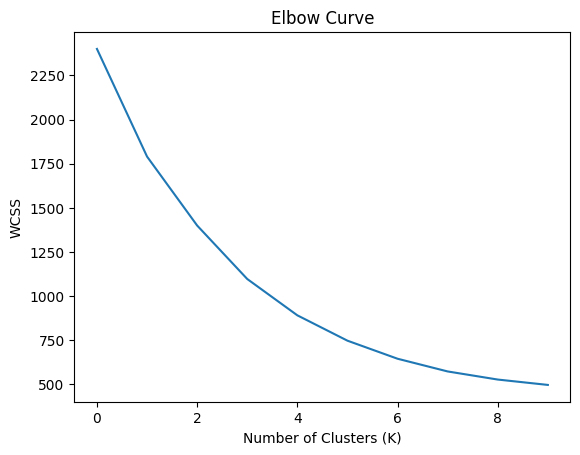

In [ ]:
# Step 4 Find value of K (Number of clusters) using Elbow Graph and WCSS
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Create Empty WCSS
wcss = []

# Test K from range 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(wcss)
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [ ]:
wcss

[2399.999999999999,
 1790.4413074667816,
 1400.0089234142415,
 1097.1797205590433,
 891.4713814971993,
 747.9136722829898,
 645.6932329260858,
 573.7096760500103,
 527.8187704849587,
 497.4227781213336]

We can notice The decrease becomes gradually smaller as K increases. Based on these values, there is not an extremely sharp elbow, but K = 3 or K = 4 are reasonable candidates.

In [181]:
# Apply K-Means
from sklearn.cluster import KMeans
# Number of cluster = 3
kmeans= KMeans(n_clusters=3, random_state = 42, n_init=10)
Target["Cluster"] = kmeans.fit_predict(features_scaled)
# Here fit_predict() means Learn the groups and assign each customer to a cluster.

Overall picture

Cluster	Main characteristic

Cluster 0	🔹 Very low satisfaction, high rating accuracy

Cluster 1	🔹 Moderate satisfaction, very low rating accuracy

Cluster 2	🔹 High satisfaction, high rating accuracy

**Task 4: Recommendation and Review Insights**

**Task 4.1 Examine the relationship between recommendation helpfulness and shopping satisfaction.**

In [ ]:
# Step 1 Accessing both columns Recommendation Helpfulness & Shopping Satisfaction to check are categorical or numerical
Target[["Recommendation_Helpfulness","Shopping_Satisfaction"]]
# Step 2 Recommendation Helpfulness vs Shopping Satisfaction
Target.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean()


,Shopping_Satisfaction
Recommendation_Helpfulness,
No,2.875472
Sometimes,2.977778
Yes,2.950943


**Task 4.2 Evaluate how review reliability and helpfulness impact overall ratings.**

In [ ]:
# Step 1 Accessing both columns Review_Reliability, Review_Helpfulness & Rating_Accuracy to check are categorical or numerical
Target[["Review_Reliability","Review_Helpfulness","Rating_Accuracy"]]
# Step 2 How Reliability and helpfulness impact overall ratings
Target.groupby(["Review_Reliability", "Review_Helpfulness"])["Rating_Accuracy"].mean().sort_values().unstack(fill_value=0)

Review_Helpfulness,No,Sometimes,Yes
Review_Reliability,,,
Heavily,3.111111,2.982759,3.142857
Moderately,2.877193,3.042553,2.916667
Never,3.408163,2.931034,2.964286
Occasionally,3.098361,3.021277,2.976190
Rarely,3.211538,3.000000,3.222222


Customers with Heavily reliable reviews and Yes for review helpfulness have an average Rating_Accuracy of 3.143.

And:

Customers with Never reliable reviews and No for review helpfulness have the highest average Rating_Accuracy of 3.408.

**Task 4.3 Identify trends in how often customers engage with or trust personalized recommendations.**

In [ ]:
# Step 1 Accessing both columns Personalized_Recommendation_Frequency_Response & Personalized_Recommendation_Frequency_Score to check are categorical or numerical
Target[["Personalized_Recommendation_Frequency_Response","Personalized_Recommendation_Frequency_Score"]]

# Step 2 Customers engagement with personalized recommendations
Target.groupby("Personalized_Recommendation_Frequency_Response")["Personalized_Recommendation_Frequency_Score"].mean()



,Personalized_Recommendation_Frequency_Score
Personalized_Recommendation_Frequency_Response,
No,2.948339
Sometimes,2.891473
Yes,3.099631


**Task 4.4 Suggest actionable insights for improving Target’s recommendation system.**

**Actionable insights for Target's recommendation system**

**1. Improve recommendation relevance**
The average shopping satisfaction was only around 3/5 across
recommendation-helpfulness groups.

Target should improve recommendations so that products are more relevant to each customer's interests and shopping behavior.

**2. Personalize recommendations based on customer behavior**
Use customers' browsing, purchase frequency, and previous purchases to provide more personalized product suggestions.

For example, frequently purchased categories can be used to recommend related products.

**3. Focus on customers who are less engaged**
Customers who responded negatively or only sometimes to personalized recommendations should receive more relevant and less repetitive recommendations.

Target could test different recommendation strategies for these customers.

**4. Use customer reviews carefully**
Your Task 4.2 results showed that review reliability/helpfulness did not have a clear, consistent relationship with rating accuracy.

Therefore, Target should not rely only on review helpfulness when deciding which products to recommend. Other signals such as purchase history and browsing behavior should also be considered.

**5. Continuously monitor recommendation performance**
Target should track whether customers actually click, purchase, or engage with recommended products.

Recommendations can then be improved based on what customers respond to.

**Task 5: Visualization and Reporting**

● Create attractive visualizations (bar charts, heatmaps, pie charts) for:

○ Purchase categories
○ Browsing frequency distribution
○ Satisfaction levels
○ Correlation between recommendation usefulness and satisfaction

**1. Purchase Categories → Bar chart**

<function matplotlib.pyplot.show(close=None, block=None)>

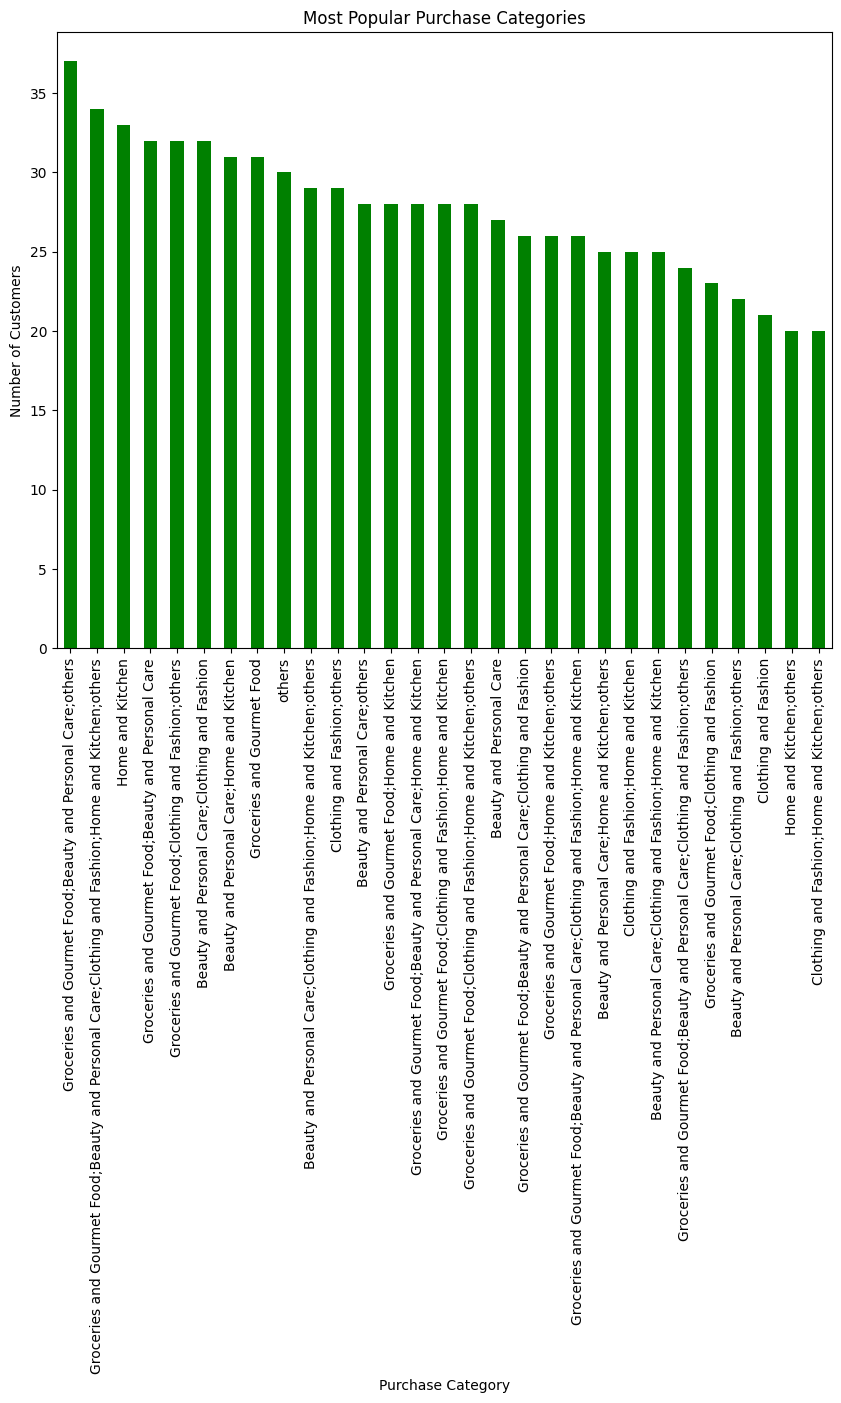

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))

order=Target["Purchase_Categories"].value_counts()
order.plot(kind="bar", color="green")
plt.title("Most Popular Purchase Categories")
plt.xlabel("Purchase Category")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)

plt.show

**The purchase category visualization shows the distribution of products purchased by customers. It helps identify the most popular product categories and provides useful information about customer purchasing preferences.**

**2. Browsing Frequency Distribution**

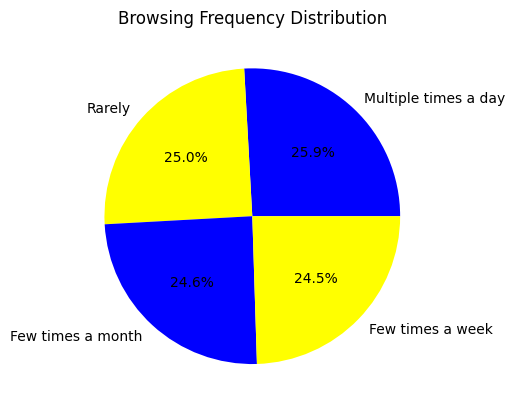

In [ ]:
b_feq = Target["Browsing_Frequency"].value_counts()


plt.pie(b_feq.values, labels=b_feq.index, autopct="%1.1f%%",colors= ["Blue", "Yellow"])
plt.title("Browsing Frequency Distribution")
plt.ylabel(" ")
plt.show()




**The browsing frequency visualization shows how often customers browse products. The distribution indicates different levels of customer engagement with the shopping platform, ranging from frequent browsing to less frequent browsing.**

**3. Satisfaction Levels**

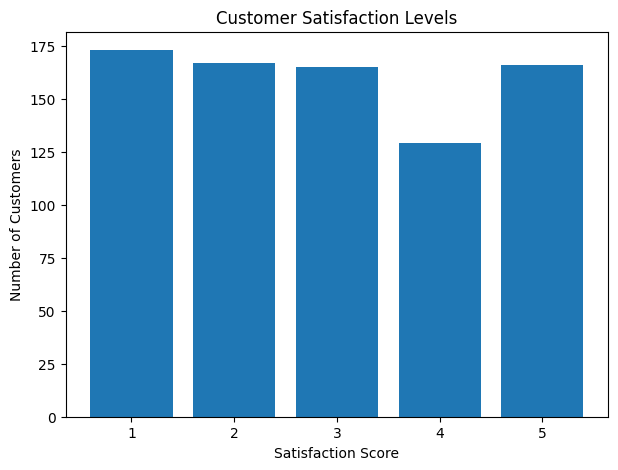

In [ ]:
b = Target["Shopping_Satisfaction"].value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.bar(b.index, b.values)

plt.title("Customer Satisfaction Levels")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.show()


**The satisfaction-level visualization shows the distribution of customer satisfaction scores. The average shopping satisfaction was 2.935, with a median of 3, indicating a moderate overall level of customer satisfaction.**

4. Recommendation usefulness vs satisfaction → Heatmap

In [ ]:
# Step 1 Accessed both "Recommendation_Helpfulness","Shopping_Satisfaction" columns
Target[["Recommendation_Helpfulness","Shopping_Satisfaction"]]

,Recommendation_Helpfulness,Shopping_Satisfaction
0,Sometimes,1
1,Sometimes,3
2,Yes,2
3,Sometimes,4
4,No,5
...,...,...
795,Sometimes,5
796,Yes,2
797,Yes,2
798,Yes,1


In [ ]:
# Step 2 Created new integer column named as Recommendation_Helpfulness_int
Target["Recommendation_Helpfulness_int"]= Target["Recommendation_Helpfulness"].map({"No":0,"Sometimes":1,"Yes":2})

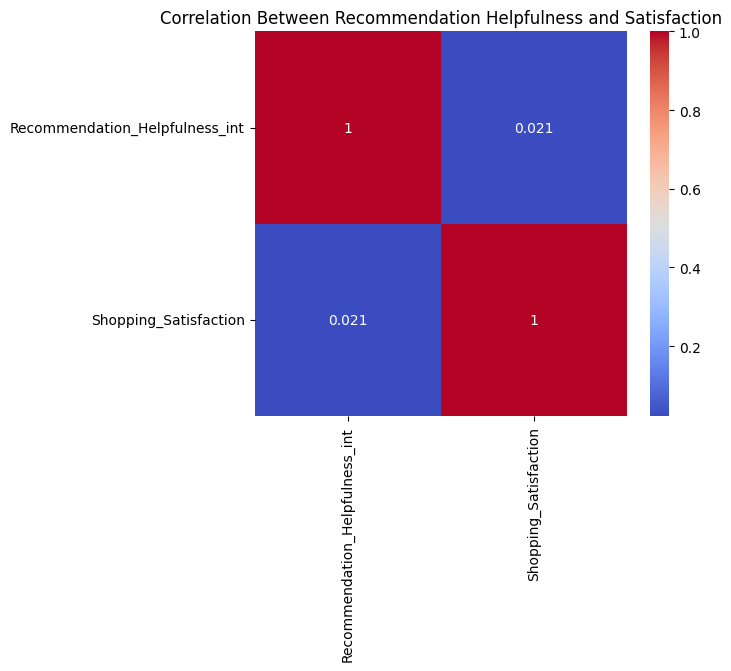

In [ ]:
# Step 3 Crete Heatmap Chart
import matplotlib.pyplot as plt
import seaborn as sns

corr = Target[[
    "Recommendation_Helpfulness_int",
    "Shopping_Satisfaction"
]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Recommendation Helpfulness and Satisfaction")
plt.show()

The analysis shows that customers who found recommendations helpful had higher satisfaction than customers who did not find them helpful. The average satisfaction scores were:

No: 2.875

Sometimes: 2.978

Yes: 2.951

In [ ]:
Target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype                    
---  ------                                          --------------  -----                    
 0   Timestamp                                       800 non-null    datetime64[ns, UTC-05:30]
 1   age                                             800 non-null    int64                    
 2   Gender                                          800 non-null    object                   
 3   Purchase_Frequency                              800 non-null    object                   
 4   Purchase_Categories                             800 non-null    object                   
 5   Personalized_Recommendation_Frequency_Response  800 non-null    object                   
 6   Browsing_Frequency                              800 non-null    object                   
 7   Product_Search_Method              